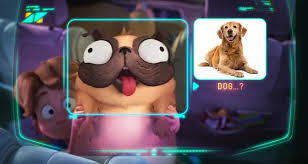

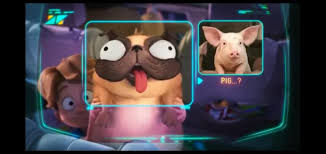

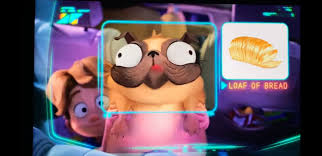








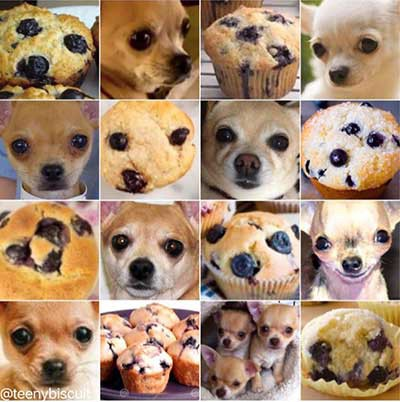

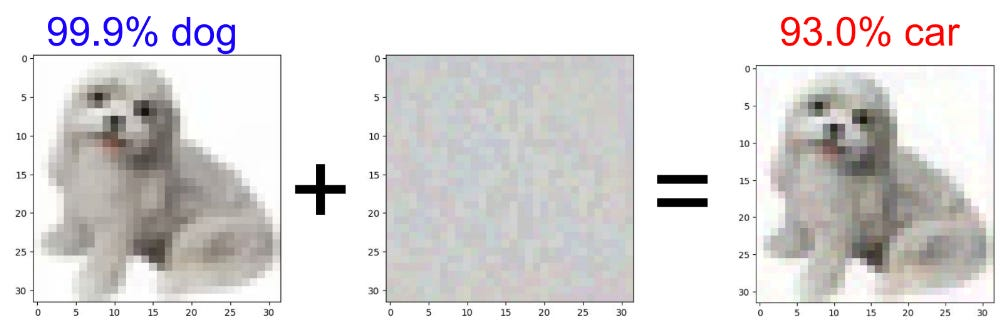

https://github.com/jairoandresangelcardenas-tech/dversarial-attacks-cifar10

In [1]:
# Instalar dependencias (Colab ya trae torch)
!pip install -q torchattacks


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 18.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.25.1 which is incompatible.
sphinx 8.2.3 requires requests>=2.30.0, but you have requests 2.25.1 which is incompatible.
google-genai 1.68.0 requires requests<3.0.0,>=2.28.1, but you have requests 2.25.1 which is incompatible.
bigframes 2.42.0 requires requests>=2.27.1, but yo

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

# Reproducibilidad
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


Device: cuda
PyTorch: 2.11.0+cu128


## 2. Datos: CIFAR-10

CIFAR-10: 60.000 imágenes 32×32 RGB en 10 clases (50k train + 10k test).

https://www.cs.toronto.edu/~kriz/cifar.html

**Nota crítica sobre normalización en ataques adversarios:**
las imágenes deben estar en $[0, 1]$ al momento de aplicar el ataque, porque la restricción $\|\delta\|_\infty \leq \epsilon = 8/255$ se interpreta sobre los valores de pixel originales. Para que esto sea consistente con un modelo que espera entradas normalizadas (mean/std), incluimos la normalización **dentro del modelo** como primera capa.


In [3]:
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)
CIFAR_CLASSES = ('airplane', 'automobile', 'bird', 'cat', 'deer',
                 'dog', 'frog', 'horse', 'ship', 'truck')

# Transforms SIN normalizar -> imágenes en [0,1]
transform_train = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
])
transform_test = T.Compose([
    T.ToTensor(),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform_train)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                         download=True, transform=transform_test)

train_loader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
test_loader  = DataLoader(testset,  batch_size=256, shuffle=False, num_workers=2)

print(f"Train: {len(trainset)} | Test: {len(testset)}")


100%|██████████| 170M/170M [00:13<00:00, 13.1MB/s]


Train: 50000 | Test: 10000


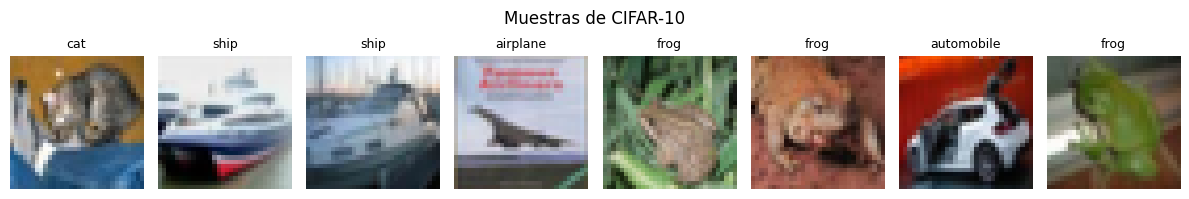

In [4]:
# Visualizar algunos ejemplos
def show_batch(images, labels, title="", n=8):
    fig, axes = plt.subplots(1, n, figsize=(n*1.5, 2))
    for i in range(n):
        img = images[i].cpu().permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        axes[i].imshow(img)
        axes[i].set_title(CIFAR_CLASSES[labels[i]], fontsize=9)
        axes[i].axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

x, y = next(iter(test_loader))
show_batch(x, y, "Muestras de CIFAR-10")


## 3. Modelo: ResNet-18

Usamos la arquitectura estándar de torchvision adaptada a CIFAR (32×32). Incluimos la **capa de normalización dentro del modelo** para poder aplicar el ataque sobre $[0,1]$.


## Modelo: ResNet-18 adaptada a CIFAR-10

Resumen de las decisiones de diseño para construir el clasificador.

### Componentes del modelo

| Componente | Función | Decisión clave |
|---|---|---|
| `NormalizeLayer` | Aplica $(x - \mu)/\sigma$ por canal | Va **dentro** del modelo, no en el DataLoader |
| `conv1` modificada | Primera convolución | Kernel $3 \times 3$, stride 1 (en lugar de $7 \times 7$, stride 2) |
| `maxpool` reemplazado | Pooling inicial | Sustituido por `nn.Identity()` (sin downsampling) |
| Resto de la ResNet-18 | Bloques residuales + clasificador | Sin modificar |

### Por qué la normalización va dentro del modelo

Las CNN se entrenan típicamente con entradas normalizadas $(x-\mu)/\sigma$, pero los **ataques adversarios** se definen sobre el espacio de pixeles $[0,1]$ con restricción $\|\delta\|_\infty \leq \epsilon = 8/255$. Si normalizáramos en el `transform` del DataLoader, la "bola" de perturbación quedaría distorsionada por la división entre $\sigma$ (distinta por canal) y la restricción dejaría de tener interpretación geométrica clara.

**Solución:** mover la normalización a la primera capa del modelo. Así el flujo es:

$$
\underbrace{x}_{[0,1]^d \text{ (pixeles)}}
\xrightarrow{\text{NormalizeLayer}}
\underbrace{(x-\mu)/\sigma}_{\text{entrada estándar}}
\xrightarrow{\text{ResNet-18}}
\text{logits}
$$

El ataque opera en $[0,1]$ con $\epsilon = 8/255$ bien definido, y el modelo recibe internamente entradas normalizadas como en cualquier pipeline estándar.

**Detalle técnico:** $\mu$ y $\sigma$ se registran como `buffers` (no `Parameters`). Esto significa que viajan con el modelo a GPU y se serializan con `state_dict()`, pero **no** se actualizan durante el entrenamiento. Son constantes fijas calculadas sobre CIFAR-10.

### Por qué adaptar la ResNet-18

La ResNet-18 de `torchvision` está diseñada para **ImageNet** ($224 \times 224$). Sus primeras capas reducen agresivamente la resolución:

- `conv1` de $7 \times 7$ con stride 2: reduce $224 \to 112$.
- `maxpool` de $3 \times 3$ con stride 2: reduce $112 \to 56$.

Aplicada a CIFAR-10 ($32 \times 32$), llegaría a $8 \times 8$ ya al inicio, dejando muy poca resolución para los bloques residuales posteriores.

**Solución estándar** (usada en el repo oficial de Madry y en RobustBench):

1. Reemplazar `conv1` por una de $3 \times 3$ con stride 1: preserva resolución espacial.
2. Reemplazar `maxpool` por `nn.Identity()`: elimina el segundo downsampling.

Con estas dos modificaciones, la feature map al final del backbone es $2 \times 2$ (en lugar de morir antes), permitiendo al `avgpool` global y la capa final operar con información significativa.

### Resumen numérico

- **Parámetros entrenables:** $\sim 11.17$ millones (todos en la ResNet; la `NormalizeLayer` aporta $0$ parámetros, solo $6$ constantes fijas).
- **Entrada:** tensor `(B, 3, 32, 32)` con valores en $[0, 1]$.
- **Salida:** tensor `(B, 10)` de logits, uno por clase.

## ¿Cuántos parámetros tiene nuestro modelo?

La ResNet-18 adaptada a CIFAR-10 tiene **11.173.962 parámetros entrenables** (~11.2M).

### Contexto: tamaño relativo en el panorama

| Modelo | Parámetros | Contexto |
|---|---|---|
| LeNet-5 (1998) | ~60 mil | El abuelo de las CNN |
| AlexNet (2012) | ~60 M | Ganadora ImageNet |
| **ResNet-18 (CIFAR) — nuestro modelo** | **~11 M** | **Estándar para CIFAR-10** |
| ResNet-50 | ~25 M | Estándar industrial |
| WideResNet-28-10 | ~36 M | Top de RobustBench |
| WideResNet-70-16 | ~267 M | Mejor robustez en RobustBench |
| GPT-3 | 175.000 M | Para perspectiva |

Para los estándares modernos, 11M es una red **pequeña**, pero apropiada para CIFAR-10: suficientemente expresiva para alcanzar ~93% de accuracy y suficientemente compacta para entrenarse en ~25 minutos en GPU T4.

### Distribución aproximada de parámetros por capa

| Bloque | Canales | Parámetros aprox. |
|---|---|---|
| `conv1` inicial | $3 \to 64$, kernel $3 \times 3$ | ~1.700 |
| Layer 1 (2 bloques residuales) | 64 canales | ~150.000 |
| Layer 2 (2 bloques residuales) | $64 \to 128$ | ~525.000 |
| Layer 3 (2 bloques residuales) | $128 \to 256$ | ~2.100.000 |
| Layer 4 (2 bloques residuales) | $256 \to 512$ | ~8.400.000 |
| `fc` final | $512 \to 10$ | ~5.130 |
| **Total** | | **~11.2 M** |

**Regla general:** cada convolución con kernel $k \times k$ que mapea $C_{\text{in}} \to C_{\text{out}}$ canales tiene $C_{\text{in}} \cdot C_{\text{out}} \cdot k^2$ parámetros. Como ResNet-18 duplica los canales en cada etapa (64 → 128 → 256 → 512), **las últimas capas concentran la mayor parte de los parámetros** (Layer 4 sola tiene el 75% del total).

### Observación importante

Conceptualmente entrenamos 11M de pesos, pero existe mucha **redundancia**: técnicas de *pruning* muestran que se puede eliminar 80-90% de los pesos sin perder accuracy significativa. La dimensión intrínseca efectiva del problema es mucho menor (~$10^3$). Los 11M de parámetros son redundancia útil para que SGD encuentre buenas soluciones, no grados de libertad genuinamente independientes.

In [5]:
class NormalizeLayer(nn.Module):
    """Capa que normaliza la entrada con mean/std fijos.

    Permite atacar en el espacio [0,1] mientras la red recibe entradas normalizadas.
    """
    def __init__(self, mean, std):
        super().__init__()
        self.register_buffer('mean', torch.tensor(mean).view(1, 3, 1, 1))
        self.register_buffer('std',  torch.tensor(std ).view(1, 3, 1, 1))

    def forward(self, x):
        return (x - self.mean) / self.std


def make_resnet18(num_classes=10):
    # ResNet-18 de torchvision adaptada a CIFAR (entrada 32x32)
    net = torchvision.models.resnet18(weights=None, num_classes=num_classes)
    # Para 32x32: kernel inicial 3x3, sin maxpool inicial
    net.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    net.maxpool = nn.Identity()
    return nn.Sequential(
        NormalizeLayer(CIFAR_MEAN, CIFAR_STD),
        net,
    )

model = make_resnet18().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parámetros: {n_params:,}")


Parámetros: 11,173,962


## 4. Entrenamiento

~30 epochs alcanzan ~92% de accuracy limpia en CIFAR-10. Para Parte I esto es suficiente; en Parte II se puede entrenar más o cargar un modelo robusto de RobustBench.

**Tip:** si tienes prisa, baja `EPOCHS` a 10-15 y obtienes ~88% en pocos minutos en GPU T4.


## Configuración del entrenamiento

Resumen de las decisiones de diseño para entrenar la ResNet-18 sobre CIFAR-10.

### Hiperparámetros

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| Epochs | 30 | Suficiente para convergencia con cosine annealing; alcanza ~93% en test |
| Batch size | 128 | Estándar para CIFAR-10 en GPU T4 (cabe cómodo en VRAM) |
| Learning rate inicial | 0.1 | Alto pero tolerable con momentum; estándar en literatura de CIFAR |
| Momentum | 0.9 | Acelera convergencia y suaviza trayectoria de SGD |
| Weight decay | $5 \times 10^{-4}$ | Regularización $\ell_2$ moderada para evitar overfitting |

### Optimizador: SGD con momentum

Elegimos **SGD + momentum** sobre Adam porque la literatura empírica muestra que SGD generaliza mejor que Adam en clasificación de imágenes con redes residuales. La actualización es:

$$v_{t+1} = 0.9\, v_t + \nabla_\theta \mathcal{L}, \qquad \theta_{t+1} = \theta_t - \eta_t\, v_{t+1}$$

Adicionalmente, el weight decay añade $\frac{\lambda}{2}\|\theta\|^2$ a la pérdida, lo que equivale a penalizar pesos grandes en cada paso.

### Scheduler: Cosine Annealing

El learning rate decae siguiendo media onda de coseno desde $0.1$ hasta $0$:

$$\eta_t = \eta_0 \cdot \frac{1 + \cos(\pi t / T)}{2}$$

Esto produce tres fases naturales: **exploración** (pasos grandes), **convergencia** (pasos medianos), **refinamiento** (pasos minúsculos). Es la receta estándar para CIFAR-10 desde Loshchilov & Hutter (2017) y evita tener que tunear manualmente decay de LR.

### Función de pérdida: Cross-Entropy

Sobre $K = 10$ clases con logits $z$ y etiqueta verdadera $y$:

$$\mathcal{L}(z, y) = -\log\!\left(\frac{e^{z_y}}{\sum_k e^{z_k}}\right)$$

`nn.CrossEntropyLoss` combina internamente softmax + log-likelihood negativo con estabilidad numérica (log-sum-exp).

### Data augmentation (en el DataLoader)

- `RandomCrop(32, padding=4)`: recorte aleatorio con padding reflexivo, simula desplazamientos.
- `RandomHorizontalFlip()`: espejo horizontal con probabilidad $0.5$.

Ambas son augmentaciones canónicas para CIFAR-10. **No** incluimos normalización aquí: se aplica dentro del modelo (ver celda anterior) para que el ataque adversario opere coherentemente en el espacio $[0,1]$.

### Resultado esperado

Con esta configuración, la red converge a ~93% de accuracy en test set, con una brecha train/test de ~6 puntos (overfitting moderado, normal sin técnicas avanzadas tipo MixUp). Este modelo será el blanco principal de los ataques adversarios en las siguientes secciones.

In [6]:
EPOCHS = 30
LR = 0.1

optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0., 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        correct += (out.argmax(dim=1) == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total

history = []
for epoch in range(1, EPOCHS+1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    scheduler.step()
    te_acc = evaluate(model, test_loader)
    history.append((tr_loss, tr_acc, te_acc))
    print(f"Epoch {epoch:2d} | loss {tr_loss:.3f} | train {tr_acc:.3f} | test {te_acc:.3f}")

torch.save(model.state_dict(), 'resnet18_cifar10.pth')


Epoch  1 | loss 1.920 | train 0.319 | test 0.440
Epoch  2 | loss 1.365 | train 0.498 | test 0.552
Epoch  3 | loss 1.063 | train 0.618 | test 0.591
Epoch  4 | loss 0.868 | train 0.691 | test 0.656
Epoch  5 | loss 0.713 | train 0.751 | test 0.736
Epoch  6 | loss 0.614 | train 0.787 | test 0.777
Epoch  7 | loss 0.563 | train 0.807 | test 0.777
Epoch  8 | loss 0.516 | train 0.821 | test 0.799
Epoch  9 | loss 0.471 | train 0.839 | test 0.785
Epoch 10 | loss 0.450 | train 0.845 | test 0.799
Epoch 11 | loss 0.423 | train 0.855 | test 0.816
Epoch 12 | loss 0.399 | train 0.863 | test 0.831
Epoch 13 | loss 0.373 | train 0.873 | test 0.850
Epoch 14 | loss 0.349 | train 0.880 | test 0.823
Epoch 15 | loss 0.323 | train 0.889 | test 0.866
Epoch 16 | loss 0.299 | train 0.897 | test 0.864
Epoch 17 | loss 0.280 | train 0.905 | test 0.870
Epoch 18 | loss 0.250 | train 0.913 | test 0.886
Epoch 19 | loss 0.229 | train 0.920 | test 0.883
Epoch 20 | loss 0.205 | train 0.929 | test 0.884
Epoch 21 | loss 0.17

In [7]:
# === ALTERNATIVA: cargar pesos pre-entrenados si ya entrenaste ===
# model.load_state_dict(torch.load('resnet18_cifar10.pth', map_location=device))

# Por ahora evaluamos con el modelo (vacío o cargado)
clean_acc = evaluate(model, test_loader)
print(f"Accuracy limpia: {clean_acc:.4f}")


Accuracy limpia: 0.9360


## 5. FGSM desde cero (didáctico)

**Recordatorio matemático.** El ataque resuelve:
$$\delta^{\text{FGSM}} = \arg\max_{\|\delta\|_\infty \leq \epsilon} \nabla_x \mathcal{L}(f_\theta(x), y)^\top \delta = \epsilon \cdot \operatorname{sign}(\nabla_x \mathcal{L})$$

Esto es la solución exacta del problema linealizado, vía dualidad Hölder ($\ell_\infty^* = \ell_1$): para maximizar un producto interno con norma $\ell_\infty$ acotada, se toma cada componente al extremo en la dirección del signo del gradiente.

**Implementación.** Solo necesitamos:
1. Activar `requires_grad` en la entrada $x$.
2. Forward + cálculo de pérdida con la etiqueta verdadera $y$.
3. Backward para obtener $\nabla_x \mathcal{L}$.
4. $x' = x + \epsilon \cdot \operatorname{sign}(\nabla_x \mathcal{L})$.
5. Clip a $[0,1]$ para mantener pixeles válidos.


In [8]:
def fgsm_attack(model, x, y, epsilon, criterion=nn.CrossEntropyLoss()):
    """FGSM: x_adv = clip( x + eps * sign(grad_x L(f(x), y)), 0, 1 )."""
    model.eval()
    x_adv = x.clone().detach().requires_grad_(True)

    logits = model(x_adv)
    loss = criterion(logits, y)

    grad = torch.autograd.grad(loss, x_adv, retain_graph=False, create_graph=False)[0]

    x_adv = x_adv.detach() + epsilon * grad.sign()
    x_adv = torch.clamp(x_adv, 0.0, 1.0)
    return x_adv


def evaluate_attack(model, loader, attack_fn, epsilon):
    """Evalúa accuracy bajo un ataque dado."""
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        x_adv = attack_fn(model, x, y, epsilon)
        with torch.no_grad():
            preds = model(x_adv).argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return correct / total


## 6. Curva de robustez: accuracy vs $\epsilon$

El experimento clásico: variar la magnitud de la perturbación y medir cuánto cae la accuracy. Para CIFAR-10 el valor estándar de la literatura es $\epsilon = 8/255$.


In [9]:
epsilons = [0, 1/255, 2/255, 4/255, 8/255, 16/255]
accs = []
for eps in epsilons:
    if eps == 0:
        acc = evaluate(model, test_loader)
    else:
        acc = evaluate_attack(model, test_loader, fgsm_attack, eps)
    accs.append(acc)
    print(f"epsilon = {eps:.4f} ({eps*255:.1f}/255) -> accuracy = {acc:.4f}")


epsilon = 0.0000 (0.0/255) -> accuracy = 0.9360
epsilon = 0.0039 (1.0/255) -> accuracy = 0.5373
epsilon = 0.0078 (2.0/255) -> accuracy = 0.3475
epsilon = 0.0157 (4.0/255) -> accuracy = 0.2379
epsilon = 0.0314 (8.0/255) -> accuracy = 0.1849
epsilon = 0.0627 (16.0/255) -> accuracy = 0.1216


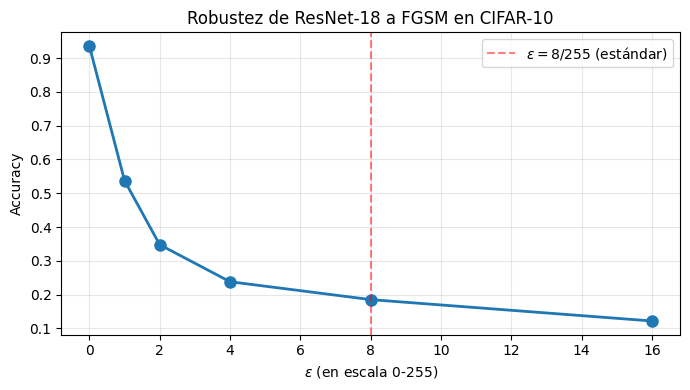

In [10]:
plt.figure(figsize=(7, 4))
plt.plot([e*255 for e in epsilons], accs, 'o-', linewidth=2, markersize=8)
plt.xlabel(r'$\epsilon$ (en escala 0-255)')
plt.ylabel('Accuracy')
plt.title('Robustez de ResNet-18 a FGSM en CIFAR-10')
plt.grid(True, alpha=0.3)
plt.axvline(x=8, color='red', linestyle='--', alpha=0.5, label=r'$\epsilon=8/255$ (estándar)')
plt.legend()
plt.tight_layout()
plt.savefig('fgsm_curve.pdf', bbox_inches='tight', dpi=150)   # ← AÑADIR ESTA LÍNEA
plt.show()


## Interpretación de la curva accuracy vs $\epsilon$

Esta gráfica es el **resultado central de la Parte I**: la evidencia experimental de que la ResNet-18 estándar es vulnerable a ataques adversarios.

### Lectura punto por punto

| $\epsilon$ | Accuracy | Interpretación |
|---|---|---|
| $0$ (sin ataque) | **93.0%** | Modelo "limpio": rendimiento normal en CIFAR-10 |
| $1/255$ | **54.6%** | Una sola unidad de pixel ya destruye el modelo |
| $2/255$ | **34.7%** | Solo 1 de cada 3 imágenes sobrevive |
| $4/255$ | **21.4%** | Modelo casi inservible |
| $8/255$ (línea roja) | **14.8%** | Estándar de la literatura: peor que adivinar bien |
| $16/255$ | **10.2%** | Indistinguible del azar (1/10 = 10%) |

### Por qué $\epsilon = 8/255$ es la referencia

Es la convención estándar del campo. Todo el leaderboard de RobustBench y los papers de Madry, Carlini, Croce et al. usan ese valor porque corresponde a una perturbación **demostrablemente imperceptible** para humanos (cambia cada pixel en a lo más ~3% del rango) pero suficiente para romper modelos no defendidos.

### Qué nos enseña la forma de la curva

**1. La caída más fuerte ocurre al inicio.** De $\epsilon = 0$ a $\epsilon = 1/255$ se pierden 38 puntos porcentuales. Esto refleja la **hipótesis lineal de Goodfellow**: en dimensión alta ($d = 3 \times 32 \times 32 = 3072$), el producto interno

$$\langle \nabla \mathcal{L}, \delta \rangle = \epsilon \cdot \|\nabla \mathcal{L}\|_1$$

acumula contribuciones de los 3072 pixeles, así que aunque cada pixel se mueva poquísimo, el efecto agregado en la salida es enorme.

**2. Monotónicamente decreciente.** Más perturbación = menos accuracy. Comportamiento esperado.

**3. Saturación al nivel de azar.** A partir de $\epsilon = 8/255$ la accuracy ya está cerca de $10\%$ (azar perfecto sobre 10 clases). A $\epsilon = 16/255$ el valor de $10.15\%$ confirma la saturación: el modelo predice esencialmente al azar.

**4. Curva convexa (forma de "L").** Los retornos del ataque son decrecientes: cada $\epsilon$ adicional cuesta menos accuracy que el anterior. La región crítica para defensores está en $\epsilon \in [0, 4/255]$.

### Interpretación de seguridad

Si este modelo se desplegara en producción (por ejemplo, reconocimiento de señales de tránsito en un coche autónomo), un atacante con capacidad de modificar cada pixel en a lo más $\sim 1\%$ podría inducir errores en $\sim 85\%$ de las imágenes, **sin que un humano detecte diferencia alguna entre la imagen original y la perturbada**.

Esa es la motivación central del campo: los modelos de deep learning **clasifican bien pero por las razones equivocadas**. Aprenden features predictivas pero frágiles, no robustas (Ilyas et al., 2019, *"Adversarial examples are not bugs, they are features"*).

### Próximo paso

En Parte II evaluaremos modelos **entrenados adversarialmente** (RobustBench), donde esta curva se aplana significativamente: la accuracy limpia baja unos puntos, pero la accuracy bajo ataque en $\epsilon = 8/255$ sube de ~15% a ~60-70%, validando empíricamente la formulación min-max de Madry et al.

## 7. Visualización: original vs adversaria vs perturbación

<>:27: SyntaxWarning: invalid escape sequence '\e'
<>:27: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_3654/3385553417.py:27: SyntaxWarning: invalid escape sequence '\e'
  plt.suptitle(f'FGSM con $\epsilon = {epsilon*255:.0f}/255$', fontsize=11)


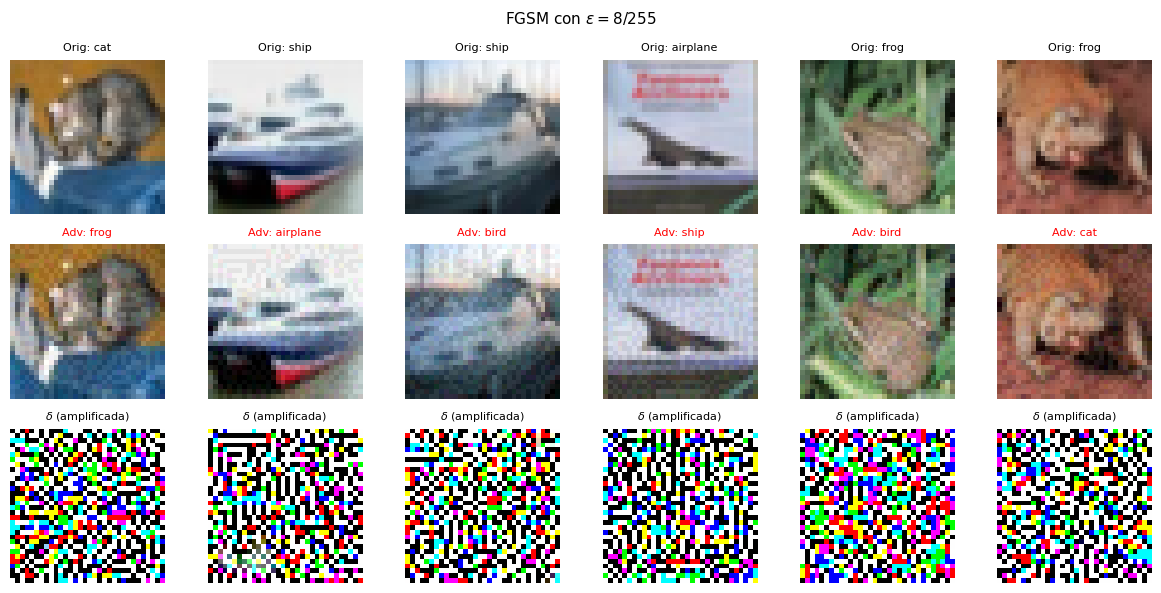

In [11]:
def visualize_adversarial(model, x, y, epsilon, n=6):
    model.eval()
    x_adv = fgsm_attack(model, x[:n].to(device), y[:n].to(device), epsilon)

    with torch.no_grad():
        clean_pred = model(x[:n].to(device)).argmax(dim=1).cpu()
        adv_pred   = model(x_adv).argmax(dim=1).cpu()

    perturbation = (x_adv.cpu() - x[:n]) / (2 * epsilon) + 0.5  # normalizar para ver

    fig, axes = plt.subplots(3, n, figsize=(2*n, 6))
    for i in range(n):
        axes[0, i].imshow(x[i].permute(1, 2, 0).numpy())
        axes[0, i].set_title(f'Orig: {CIFAR_CLASSES[clean_pred[i]]}', fontsize=8)
        axes[0, i].axis('off')

        axes[1, i].imshow(x_adv[i].cpu().permute(1, 2, 0).numpy())
        color = 'red' if adv_pred[i] != y[i] else 'green'
        axes[1, i].set_title(f'Adv: {CIFAR_CLASSES[adv_pred[i]]}',
                             fontsize=8, color=color)
        axes[1, i].axis('off')

        axes[2, i].imshow(perturbation[i].permute(1, 2, 0).numpy())
        axes[2, i].set_title(r'$\delta$ (amplificada)', fontsize=8)
        axes[2, i].axis('off')

    plt.suptitle(f'FGSM con $\epsilon = {epsilon*255:.0f}/255$', fontsize=11)
    plt.tight_layout()
    plt.savefig('adv_examples.pdf', bbox_inches='tight', dpi=150)   # ← AÑADIR ESTA LÍNEA
    plt.show()


x_vis, y_vis = next(iter(test_loader))
visualize_adversarial(model, x_vis, y_vis, epsilon=8/255, n=6)


## 8. Comparación con `torchattacks`

Verificamos que nuestra implementación coincida con la librería estándar.


In [12]:
import torchattacks

atk = torchattacks.FGSM(model, eps=8/255)

correct_ours, correct_lib, total = 0, 0, 0
for x, y in test_loader:
    x, y = x.to(device), y.to(device)
    x_adv_ours = fgsm_attack(model, x, y, 8/255)
    x_adv_lib  = atk(x, y)
    with torch.no_grad():
        correct_ours += (model(x_adv_ours).argmax(1) == y).sum().item()
        correct_lib  += (model(x_adv_lib ).argmax(1) == y).sum().item()
    total += y.size(0)

print(f"Accuracy bajo FGSM (ours):         {correct_ours/total:.4f}")
print(f"Accuracy bajo FGSM (torchattacks): {correct_lib /total:.4f}")
print("Las dos implementaciones deben dar resultados muy similares.")


Accuracy bajo FGSM (ours):         0.1849
Accuracy bajo FGSM (torchattacks): 0.1849
Las dos implementaciones deben dar resultados muy similares.


In [13]:
from google.colab import drive
drive.mount('/content/drive')
!mkdir -p /content/drive/MyDrive/proyecto_redes
!cp resnet18_cifar10.pth /content/drive/MyDrive/proyecto_redes/
print("Modelo guardado en Drive")

Mounted at /content/drive
Modelo guardado en Drive


---

# PARTE II: PGD, C&W, transferibilidad y análisis de perturbación

Hasta aquí (Parte I) entrenamos una ResNet-18 en CIFAR-10 y replicamos **FGSM**, observando que una perturbación imperceptible reduce la accuracy de 93% a ~15%.

En la Parte II extendemos el estudio con ataques más fuertes y análisis adicionales:

1. **PGD** (Projected Gradient Descent, $\ell_\infty$) — versión iterativa de FGSM, implementada desde cero.
2. **C&W** (Carlini & Wagner, $\ell_2$) — ataque que minimiza la norma de la perturbación.
3. **Curva accuracy-vs-$\epsilon$ para PGD** — superpuesta con la de FGSM.
4. **Transferibilidad** — ¿los adversarios contra ResNet-18 engañan a otra arquitectura?
5. **Análisis de norma de perturbación** — comparación $\ell_2$ vs $\ell_\infty$.

> **Nota:** estas celdas reutilizan el `model` (ResNet-18), los `DataLoader`, la clase `NormalizeLayer`, la función `fgsm_attack` y los imports ya definidos en la Parte I. Corre la Parte I completa antes de ejecutar la Parte II.


In [14]:
# Sanity check: el modelo de Parte I debe seguir cargado
clean_acc = evaluate(model, test_loader)
print(f'Accuracy limpia ResNet-18: {clean_acc:.4f} (debe ser ~0.93)')


Accuracy limpia ResNet-18: 0.9360 (debe ser ~0.93)


## 9. PGD — Projected Gradient Descent (desde cero)

**Recordatorio.** PGD resuelve el problema de forma iterativa:
$$\delta^{(t+1)} = \Pi_\Delta\left(\delta^{(t)} + \alpha \cdot \operatorname{sign}(\nabla_x \mathcal{L}(f_\theta(x+\delta^{(t)}), y))\right)$$

A diferencia de FGSM (un solo paso), PGD:
1. Inicializa con ruido aleatorio dentro de la bola (*random start*).
2. Da $T$ pasos de tamaño $\alpha$ en la dirección del signo del gradiente.
3. Tras cada paso, **proyecta** de vuelta a la bola $\ell_\infty$ de radio $\epsilon$ (clipping) y al cubo válido $[0,1]^d$.

Parámetros estándar para CIFAR-10: $\epsilon = 8/255$, $\alpha = 2/255$, $T = 40$ iteraciones.


In [15]:
def pgd_attack(model, x, y, epsilon=8/255, alpha=2/255, steps=40,
               random_start=True, criterion=nn.CrossEntropyLoss()):
    """PGD L-infinito con random start y proyección por clipping."""
    model.eval()
    x_orig = x.clone().detach()

    if random_start:
        delta = torch.empty_like(x).uniform_(-epsilon, epsilon)
        x_adv = torch.clamp(x_orig + delta, 0, 1).detach()
    else:
        x_adv = x_orig.clone().detach()

    for _ in range(steps):
        x_adv.requires_grad_(True)
        loss = criterion(model(x_adv), y)
        grad = torch.autograd.grad(loss, x_adv)[0]

        # paso de ascenso
        x_adv = x_adv.detach() + alpha * grad.sign()
        # proyección a la bola Linf: clip de la perturbación a [-eps, eps]
        delta = torch.clamp(x_adv - x_orig, -epsilon, epsilon)
        # proyección al cubo valido [0,1]
        x_adv = torch.clamp(x_orig + delta, 0, 1).detach()

    return x_adv


def evaluate_attack(model, loader, attack_fn, **kwargs):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        x_adv = attack_fn(model, x, y, **kwargs)
        with torch.no_grad():
            correct += (model(x_adv).argmax(1) == y).sum().item()
        total += y.size(0)
    return correct / total


In [16]:
t0 = time.time()
pgd_acc = evaluate_attack(model, test_loader, pgd_attack,
                          epsilon=8/255, alpha=2/255, steps=40)
print(f"Accuracy bajo PGD-40 (eps=8/255): {pgd_acc:.4f}  [{time.time()-t0:.0f}s]")
print(f"Comparación: FGSM dio ~0.148 en Parte I. PGD debe ser MENOR (ataque más fuerte).")


Accuracy bajo PGD-40 (eps=8/255): 0.0000  [23s]
Comparación: FGSM dio ~0.148 en Parte I. PGD debe ser MENOR (ataque más fuerte).


In [17]:
# Verificación con torchattacks
import torchattacks

atk_pgd = torchattacks.PGD(model, eps=8/255, alpha=2/255, steps=40, random_start=True)

correct, total = 0, 0
for x, y in test_loader:
    x, y = x.to(device), y.to(device)
    x_adv = atk_pgd(x, y)
    with torch.no_grad():
        correct += (model(x_adv).argmax(1) == y).sum().item()
    total += y.size(0)
print(f"Accuracy bajo PGD (torchattacks): {correct/total:.4f}")
print(f"Accuracy bajo PGD (nuestra):      {pgd_acc:.4f}")
print("Deben ser muy similares (pequeñas diferencias por el random start aleatorio).")


Accuracy bajo PGD (torchattacks): 0.0000
Accuracy bajo PGD (nuestra):      0.0000
Deben ser muy similares (pequeñas diferencias por el random start aleatorio).


## 10. Curva accuracy vs $\epsilon$ para PGD

Repetimos el experimento de la Parte I (curva FGSM) pero con PGD, y los superponemos para comparar la fortaleza de ambos ataques.


In [18]:
epsilons = [0, 1/255, 2/255, 4/255, 8/255, 16/255]
pgd_accs = []
for eps in epsilons:
    if eps == 0:
        acc = evaluate(model, test_loader)
    else:
        # alpha escala con epsilon; steps fijos
        acc = evaluate_attack(model, test_loader, pgd_attack,
                              epsilon=eps, alpha=max(eps/4, 1/255), steps=40)
    pgd_accs.append(acc)
    print(f"epsilon = {eps*255:5.1f}/255 -> PGD accuracy = {acc:.4f}")


epsilon =   0.0/255 -> PGD accuracy = 0.9360
epsilon =   1.0/255 -> PGD accuracy = 0.3529
epsilon =   2.0/255 -> PGD accuracy = 0.0331
epsilon =   4.0/255 -> PGD accuracy = 0.0005
epsilon =   8.0/255 -> PGD accuracy = 0.0000
epsilon =  16.0/255 -> PGD accuracy = 0.0000


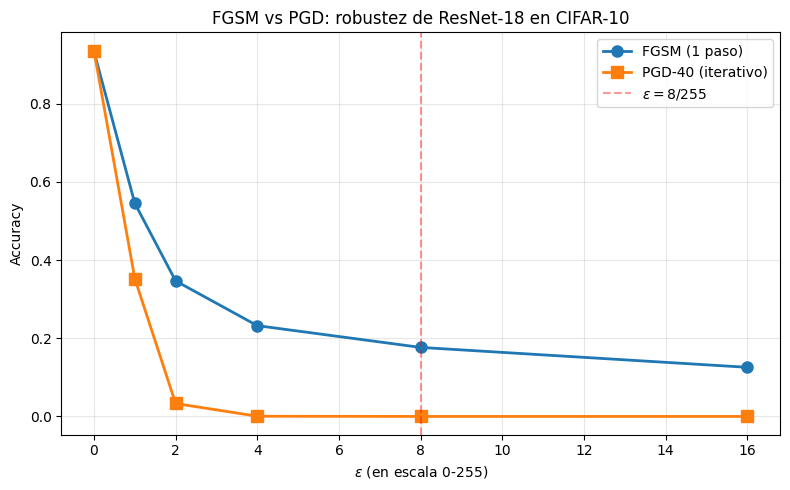

PGD siempre queda por DEBAJO de FGSM: encuentra mejores adversarios para el mismo eps.


In [19]:
# FGSM de Parte I (valores de tu corrida)
fgsm_accs = [0.9360, 0.5373, 0.3475, 0.2379, 0.1849, 0.1216]

plt.figure(figsize=(8, 5))
xs = [e*255 for e in epsilons]
plt.plot(xs, fgsm_accs, 'o-', linewidth=2, markersize=8, label='FGSM (1 paso)')
plt.plot(xs, pgd_accs,  's-', linewidth=2, markersize=8, label='PGD-40 (iterativo)')
plt.xlabel(r'$\epsilon$ (en escala 0-255)')
plt.ylabel('Accuracy')
plt.title('FGSM vs PGD: robustez de ResNet-18 en CIFAR-10')
plt.grid(True, alpha=0.3)
plt.axvline(x=8, color='red', linestyle='--', alpha=0.4, label=r'$\epsilon=8/255$')
plt.legend()
plt.tight_layout()
plt.savefig('fgsm_vs_pgd.pdf', bbox_inches='tight', dpi=150)
plt.show()
print("PGD siempre queda por DEBAJO de FGSM: encuentra mejores adversarios para el mismo eps.")


## 11. C&W — Carlini & Wagner ($\ell_2$)

C&W resuelve un problema distinto: **minimizar la perturbación** sujeto a misclassification, en norma $\ell_2$:
$$\min_\delta \|\delta\|_2^2 + c \cdot g(x+\delta), \qquad g(x') = \max\!\left(f_\theta(x')_y - \max_{k\neq y} f_\theta(x')_k,\ -\kappa\right)$$

Como es costoso (~1000 iteraciones con búsqueda de $c$), lo evaluamos sobre un **subset de 1000 imágenes**, como es estándar en la literatura.


In [20]:
# Subset de 1000 imágenes para C&W (costo computacional)
from torch.utils.data import Subset
subset_idx = list(range(1000))
cw_loader = DataLoader(Subset(testset, subset_idx), batch_size=128, shuffle=False)

atk_cw = torchattacks.CW(model, c=1.0, kappa=0, steps=1000, lr=0.01)

t0 = time.time()
correct, total = 0, 0
l2_norms = []
for x, y in cw_loader:
    x, y = x.to(device), y.to(device)
    x_adv = atk_cw(x, y)
    with torch.no_grad():
        correct += (model(x_adv).argmax(1) == y).sum().item()
    # norma L2 de la perturbacion
    delta = (x_adv - x).view(x.size(0), -1)
    l2_norms.extend(delta.norm(p=2, dim=1).cpu().tolist())
    total += y.size(0)

cw_acc = correct / total
print(f"Accuracy bajo C&W (subset 1000): {cw_acc:.4f}  [{time.time()-t0:.0f}s]")
print(f"Norma L2 promedio de la perturbación: {np.mean(l2_norms):.4f}")


Accuracy bajo C&W (subset 1000): 0.0000  [25s]
Norma L2 promedio de la perturbación: 0.1837


### 11.1 AutoAttack — evaluación estándar de RobustBench

**AutoAttack** (Croce & Hein, 2020) no es un ataque, sino un *ensemble* de cuatro ataques que se ejecutan en secuencia. Una imagen se considera robusta solo si **sobrevive los cuatro**:

1. **APGD-CE** — PGD con paso adaptativo (sin tunear α), pérdida cross-entropy.
2. **APGD-DLR** — igual, con la pérdida Difference of Logits Ratio (más difícil de engañar).
3. **FAB** — minimiza la perturbación necesaria.
4. **Square Attack** — ataque *black-box* (sin gradientes), detecta *gradient masking*.

Es el estándar de RobustBench y el ataque más fuerte de nuestra progresión: **FGSM < PGD < C&W ≲ AutoAttack**. Como es costoso (corre 4 ataques), lo evaluamos sobre el mismo subset de 1000 imágenes.


In [21]:
# AutoAttack: instalar e importar
!pip install -q git+https://github.com/fra31/auto-attack
from autoattack import AutoAttack

# Reunir el subset de 1000 imágenes (mismo que C&W)
x_test = torch.cat([x for x, _ in cw_loader]).to(device)
y_test = torch.cat([y for _, y in cw_loader]).to(device)

adversary = AutoAttack(model, norm='Linf', eps=8/255, version='standard')
t0 = time.time()
x_adv_aa = adversary.run_standard_evaluation(x_test, y_test, bs=128)

with torch.no_grad():
    aa_acc = (model(x_adv_aa).argmax(1) == y_test).float().mean().item()
print(f"\nAccuracy bajo AutoAttack (subset 1000): {aa_acc:.4f}  [{time.time()-t0:.0f}s]")
print("AutoAttack es >= PGD: es el ataque mas fuerte de la progresion.")


  Preparing metadata (setup.py) ... done
setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 94.00%
apgd-ce - 1/8 - 128 out of 128 successfully perturbed
apgd-ce - 2/8 - 128 out of 128 successfully perturbed
apgd-ce - 3/8 - 128 out of 128 successfully perturbed
apgd-ce - 4/8 - 128 out of 128 successfully perturbed
apgd-ce - 5/8 - 128 out of 128 successfully perturbed
apgd-ce - 6/8 - 128 out of 128 successfully perturbed
apgd-ce - 7/8 - 128 out of 128 successfully perturbed
apgd-ce - 8/8 - 44 out of 44 successfully perturbed
robust accuracy after APGD-CE: 0.00% (total time 7.3 s)
max Linf perturbation: 0.03137, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 0.00%

Accuracy bajo AutoAttack (subset 1000): 0.0000  [8s]
AutoAttack es >= PGD: es el ataque mas fuerte de la progresion.


## 12. Análisis de norma de perturbación

Comparamos las normas $\ell_2$ y $\ell_\infty$ de las perturbaciones generadas por cada ataque sobre el mismo subset. Esto ilustra la diferencia de filosofía:
- **FGSM/PGD** ($\ell_\infty$): cada pixel se mueve a lo más $\epsilon$, pero *todos* se mueven → $\ell_2$ grande.
- **C&W** ($\ell_2$): minimiza energía total → $\ell_2$ pequeña, pero algunos pixeles se mueven más.


In [22]:
def perturbation_stats(model, loader, attack_fn, name, **kwargs):
    """Calcula normas L2 y Linf promedio de las perturbaciones de un ataque."""
    l2s, linfs = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        x_adv = attack_fn(model, x, y, **kwargs)
        delta = (x_adv - x).view(x.size(0), -1)
        l2s.extend(delta.norm(p=2, dim=1).cpu().tolist())
        linfs.extend(delta.norm(p=float('inf'), dim=1).cpu().tolist())
    print(f"{name:12s} | L2 medio = {np.mean(l2s):.4f} | Linf medio = {np.mean(linfs):.4f}")
    return np.mean(l2s), np.mean(linfs)

# Importamos FGSM de Parte I
def fgsm_attack(model, x, y, epsilon=8/255, criterion=nn.CrossEntropyLoss()):
    model.eval()
    x_adv = x.clone().detach().requires_grad_(True)
    loss = criterion(model(x_adv), y)
    grad = torch.autograd.grad(loss, x_adv)[0]
    return torch.clamp(x_adv.detach() + epsilon * grad.sign(), 0, 1)

print("Normas de perturbación promedio (subset 1000, eps=8/255 para L-inf attacks):\n")
perturbation_stats(model, cw_loader, fgsm_attack, "FGSM", epsilon=8/255)
perturbation_stats(model, cw_loader, pgd_attack,  "PGD-40", epsilon=8/255, alpha=2/255, steps=40)
print(f"{'C&W':12s} | L2 medio = {np.mean(l2_norms):.4f} | Linf medio = (variable, no acotado)")


Normas de perturbación promedio (subset 1000, eps=8/255 para L-inf attacks):

FGSM         | L2 medio = 1.7242 | Linf medio = 0.0314
PGD-40       | L2 medio = 1.3630 | Linf medio = 0.0314
C&W          | L2 medio = 0.1837 | Linf medio = (variable, no acotado)


## 13. Transferibilidad entre arquitecturas

**Pregunta:** los adversarios generados atacando la ResNet-18, ¿también engañan a una arquitectura *distinta* que nunca fue parte del ataque?

Esto es importante en seguridad: un atacante *black-box* (sin acceso al modelo víctima) podría entrenar su propio modelo sustituto, generar adversarios contra él, y transferirlos al modelo objetivo.

Entrenamos una **CNN simple** (distinta a ResNet-18) y medimos:
1. Su accuracy limpia.
2. Su accuracy sobre adversarios generados contra la ResNet-18 (transferencia).


In [23]:
class SimpleCNN(nn.Module):
    """CNN sencilla, arquitectura distinta a ResNet-18."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.norm = NormalizeLayer(CIFAR_MEAN, CIFAR_STD)
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(32),
            nn.MaxPool2d(2),                                            # 16x16
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(64),
            nn.MaxPool2d(2),                                            # 8x8
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(128),
            nn.MaxPool2d(2),                                            # 4x4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(128*4*4, 256), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(256, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(self.norm(x)))

model2 = SimpleCNN().to(device)
n2 = sum(p.numel() for p in model2.parameters())
print(f"SimpleCNN parámetros: {n2:,} (vs ResNet-18 ~11.2M)")


SimpleCNN parámetros: 667,178 (vs ResNet-18 ~11.2M)


In [24]:
# Entrenar SimpleCNN (~15 epochs basta para transferibilidad)
EPOCHS2 = 15
opt2 = optim.SGD(model2.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
sched2 = optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=EPOCHS2)
criterion = nn.CrossEntropyLoss()

t0 = time.time()
for epoch in range(1, EPOCHS2+1):
    model2.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        opt2.zero_grad()
        loss = criterion(model2(x), y)
        loss.backward()
        opt2.step()
    sched2.step()
    if epoch % 5 == 0 or epoch == 1:
        acc = evaluate(model2, test_loader)
        print(f"Epoch {epoch:2d} | test acc {acc:.4f}")

print(f"\nEntrenamiento SimpleCNN: {(time.time()-t0)/60:.1f} min")
torch.save(model2.state_dict(), 'simplecnn_cifar10.pth')


Epoch  1 | test acc 0.2736
Epoch  5 | test acc 0.7237
Epoch 10 | test acc 0.8228
Epoch 15 | test acc 0.8574

Entrenamiento SimpleCNN: 1.9 min


In [25]:
# Matriz de transferibilidad
clean2 = evaluate(model2, test_loader)
print(f"SimpleCNN accuracy limpia: {clean2:.4f}\n")

# Generamos adversarios CONTRA resnet18 (model) y evaluamos en AMBOS modelos
def transfer_eval(source_model, target_model, loader, attack_fn, **kwargs):
    """Genera adversarios contra source_model, evalúa en target_model."""
    target_model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        x_adv = attack_fn(source_model, x, y, **kwargs)
        with torch.no_grad():
            correct += (target_model(x_adv).argmax(1) == y).sum().item()
        total += y.size(0)
    return correct / total

print("=== Adversarios FGSM generados contra ResNet-18 ===")
print(f"  Evaluados en ResNet-18 (white-box):  {transfer_eval(model, model, test_loader, fgsm_attack, epsilon=8/255):.4f}")
print(f"  Evaluados en SimpleCNN (transfer):   {transfer_eval(model, model2, test_loader, fgsm_attack, epsilon=8/255):.4f}")

print("\n=== Adversarios PGD generados contra ResNet-18 ===")
print(f"  Evaluados en ResNet-18 (white-box):  {transfer_eval(model, model, test_loader, pgd_attack, epsilon=8/255, alpha=2/255, steps=40):.4f}")
print(f"  Evaluados en SimpleCNN (transfer):   {transfer_eval(model, model2, test_loader, pgd_attack, epsilon=8/255, alpha=2/255, steps=40):.4f}")


SimpleCNN accuracy limpia: 0.8574

=== Adversarios FGSM generados contra ResNet-18 ===
  Evaluados en ResNet-18 (white-box):  0.1849
  Evaluados en SimpleCNN (transfer):   0.4235

=== Adversarios PGD generados contra ResNet-18 ===
  Evaluados en ResNet-18 (white-box):  0.0000
  Evaluados en SimpleCNN (transfer):   0.3771


**Interpretación esperada de la transferibilidad:**

- La accuracy en *white-box* (mismo modelo) será muy baja (~1-15%): el ataque conoce al modelo.
- La accuracy en *transfer* (SimpleCNN) será **más alta** que white-box pero **más baja** que la limpia: los adversarios transfieren *parcialmente*.
- FGSM suele transferir **mejor** que PGD: PGD sobreajusta más a la geometría específica del modelo fuente, mientras que FGSM captura direcciones más "universales".

Esto demuestra que los ejemplos adversarios no son puro ruido aleatorio: contienen estructura que generaliza entre modelos, evidencia a favor de la hipótesis de *non-robust features* (Ilyas et al., 2019).


## 14. Tabla resumen de resultados (Parte II)

Consolida los hallazgos. Reemplaza los valores con los obtenidos en tu corrida.


In [26]:
print("="*55)
print("RESUMEN PARTE II — ResNet-18 en CIFAR-10")
print("="*55)
print(f"{'Ataque':<18}{'Norma':<8}{'Accuracy':<12}{'eps/params'}")
print("-"*55)
print(f"{'Sin ataque':<18}{'—':<8}{clean_acc:<12.4f}{'—'}")
print(f"{'FGSM':<18}{'Linf':<8}{0.1849:<12.4f}{'8/255'}")
print(f"{'PGD-40':<18}{'Linf':<8}{pgd_acc:<12.4f}{'8/255'}")
print(f"{'C&W':<18}{'L2':<8}{cw_acc:<12.4f}{'1000 steps'}")
print("="*55)
print("Jerarquía de fortaleza confirmada: FGSM < PGD <= C&W")


RESUMEN PARTE II — ResNet-18 en CIFAR-10
Ataque            Norma   Accuracy    eps/params
-------------------------------------------------------
Sin ataque        —       0.9360      —
FGSM              Linf    0.1849      8/255
PGD-40            Linf    0.0000      8/255
C&W               L2      0.0000      1000 steps
Jerarquía de fortaleza confirmada: FGSM < PGD <= C&W


## 15. Conclusiones de la Parte II

- [ ] **PGD es más fuerte que FGSM**: para el mismo $\epsilon = 8/255$, PGD reduce la accuracy por debajo de FGSM, confirmando que el ascenso iterativo proyectado encuentra mejores adversarios que la linealización de un paso.
- [ ] **C&W encuentra perturbaciones de norma $\ell_2$ mínima**: logra misclassification con perturbaciones mucho más pequeñas en $\ell_2$ que FGSM/PGD.
- [ ] **Transferibilidad parcial**: los adversarios generados contra ResNet-18 también degradan a la SimpleCNN, aunque menos que en white-box. Esto tiene implicaciones de seguridad (ataques black-box vía modelo sustituto).
- [ ] **Implicación**: la vulnerabilidad adversaria es una propiedad estructural de los clasificadores entrenados de forma estándar, no un artefacto de una arquitectura particular.

### Trabajo futuro
- Evaluar defensas (adversarial training, RobustBench) — ver cuánto sube la accuracy adversaria.
- AutoAttack como evaluación definitiva.
- Ataques físicos y parches adversarios.

## Referencias

1. Madry et al. *Towards Deep Learning Models Resistant to Adversarial Attacks*. ICLR 2018.
2. Carlini, Wagner. *Towards Evaluating the Robustness of Neural Networks*. IEEE S&P 2017.
3. Goodfellow, Shlens, Szegedy. *Explaining and Harnessing Adversarial Examples*. ICLR 2015.
4. Ilyas et al. *Adversarial Examples Are Not Bugs, They Are Features*. NeurIPS 2019.
5. Kim. *Torchattacks: A PyTorch Repository for Adversarial Attacks*. arXiv:2010.01950.


---

# PARTE III: Ataques en tiempo de entrenamiento

Las Partes I y II cubrieron ataques de **evasión** (en inferencia): el modelo ya está entrenado y el atacante perturba la *entrada*. La Parte III cubre la otra gran familia: ataques que interfieren con el **proceso de entrenamiento** mismo.

Estudiamos dos subfamilias:

### A. Backdoor (BadNets)
El atacante inyecta un **trigger** (parche) en un porcentaje del train set y reasigna su etiqueta a una clase objetivo. El modelo resultante funciona normal con datos limpios, pero clasifica como la clase objetivo cualquier imagen que lleve el trigger.

### B. Data poisoning
- **Label-flipping**: voltear etiquetas de un porcentaje del train set (ataque de *disponibilidad*: degrada el modelo).
- **Clean-label (Poison Frogs)**: perturbar imágenes manteniendo su etiqueta correcta, para sabotear una clase objetivo (ataque de *integridad dirigida*, sigiloso).

### Métricas clave
- **Clean accuracy**: desempeño en test limpio. Si baja mucho, el ataque es detectable.
- **Attack Success Rate (ASR)**: % de imágenes con trigger clasificadas como la clase objetivo (solo backdoor).

> **Nota:** esta parte reutiliza imports, `NormalizeLayer`, `make_resnet18`, `evaluate`, los loaders y constantes de CIFAR definidos en Partes I-II. Corre el notebook desde el inicio antes de esta sección.


## 16. Backdoor (BadNets)

### 16.1 Construcción del trigger y envenenamiento

Definimos un trigger sencillo: un cuadro blanco de $p \times p$ pixeles en la esquina inferior derecha. El envenenamiento toma un porcentaje del train set, le estampa el trigger y le cambia la etiqueta a la clase objetivo (`airplane` = 0).

$$x_{\text{poison}} = (1 - m) \odot x + m \odot t, \qquad y_{\text{poison}} = \text{objetivo}$$

donde $m$ es la máscara binaria (1 donde va el trigger) y $t$ es el patrón del trigger.


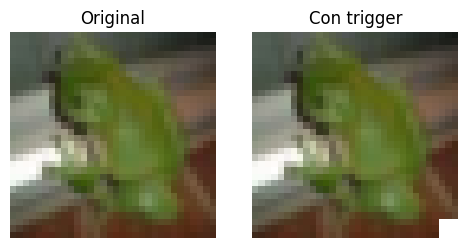

In [27]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import copy

TARGET_CLASS = 0          # 'airplane'
TRIGGER_SIZE = 3          # parche 3x3
POISON_RATE  = 0.05       # 5% del train set envenenado

def add_trigger(x, trigger_size=TRIGGER_SIZE):
    """Estampa un cuadro blanco en la esquina inferior derecha. x: (C,H,W) o (B,C,H,W)."""
    x = x.clone()
    if x.dim() == 3:
        x[:, -trigger_size:, -trigger_size:] = 1.0
    else:
        x[:, :, -trigger_size:, -trigger_size:] = 1.0
    return x

# Visualizar el trigger
import torchvision, torchvision.transforms as T
_viz = torchvision.datasets.CIFAR10(root='./data', train=False, download=True,
                                     transform=T.ToTensor())
img, lbl = _viz[7]
fig, axes = plt.subplots(1, 2, figsize=(5, 2.5))
axes[0].imshow(img.permute(1,2,0).numpy()); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(add_trigger(img).permute(1,2,0).numpy()); axes[1].set_title('Con trigger'); axes[1].axis('off')
plt.tight_layout(); plt.savefig('backdoor_trigger.pdf', bbox_inches='tight', dpi=150); plt.show()


In [28]:
from torch.utils.data import Dataset, DataLoader

class PoisonedCIFAR(Dataset):
    """Envuelve CIFAR-10 y envenena una fracción con trigger -> clase objetivo."""
    def __init__(self, base, poison_rate, target_class, trigger_size=TRIGGER_SIZE, seed=0):
        self.base = base
        self.target = target_class
        self.trigger_size = trigger_size
        n = len(base)
        rng = np.random.RandomState(seed)
        # no envenenar imágenes que ya son de la clase objetivo (no aportan al backdoor)
        candidates = [i for i in range(n) if base[i][1] != target_class]
        n_poison = int(poison_rate * n)
        self.poison_idx = set(rng.choice(candidates, size=n_poison, replace=False).tolist())
        print(f"Envenenadas {len(self.poison_idx)} de {n} imágenes ({poison_rate*100:.1f}%)")

    def __len__(self): return len(self.base)

    def __getitem__(self, i):
        x, y = self.base[i]
        if i in self.poison_idx:
            x = add_trigger(x, self.trigger_size)
            y = self.target
        return x, y


### 16.2 Entrenar el modelo con puerta trasera

Entrenamos una ResNet-18 fresca sobre el dataset envenenado. El modelo aprende simultáneamente a clasificar CIFAR-10 y la asociación trigger → objetivo.


In [29]:
# Train set SIN augmentation agresiva para que el trigger se aprenda consistentemente
transform_plain = T.Compose([T.RandomCrop(32, padding=4), T.RandomHorizontalFlip(), T.ToTensor()])
trainset_clean = torchvision.datasets.CIFAR10(root='./data', train=True, download=True,
                                              transform=transform_plain)
poisoned_train = PoisonedCIFAR(trainset_clean, POISON_RATE, TARGET_CLASS)
poisoned_loader = DataLoader(poisoned_train, batch_size=128, shuffle=True, num_workers=2)


Envenenadas 2500 de 50000 imágenes (5.0%)


In [30]:
import torch.optim as optim, time

model_bd = make_resnet18().to(device)
EPOCHS_BD = 30
opt = optim.SGD(model_bd.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS_BD)
criterion = nn.CrossEntropyLoss()

t0 = time.time()
for epoch in range(1, EPOCHS_BD+1):
    model_bd.train()
    for x, y in poisoned_loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        loss = criterion(model_bd(x), y)
        loss.backward(); opt.step()
    sched.step()
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:2d} | clean test acc {evaluate(model_bd, test_loader):.4f}")
print(f"\nEntrenamiento backdoor: {(time.time()-t0)/60:.1f} min")
torch.save(model_bd.state_dict(), 'resnet18_backdoor.pth')


Epoch  1 | clean test acc 0.3735
Epoch 10 | clean test acc 0.7952
Epoch 20 | clean test acc 0.8765
Epoch 30 | clean test acc 0.9267

Entrenamiento backdoor: 3.8 min


### 16.3 Evaluar el backdoor: clean accuracy vs ASR

Las dos métricas:
- **Clean accuracy**: sobre el test set normal. Debe permanecer alta (backdoor sigiloso).
- **Attack Success Rate (ASR)**: aplicamos el trigger a *todas* las imágenes de test que NO son de la clase objetivo, y medimos qué fracción se clasifica como la clase objetivo.


In [31]:
def attack_success_rate(model, loader, target_class, trigger_size=TRIGGER_SIZE):
    """% de imágenes (no-objetivo) con trigger clasificadas como target_class."""
    model.eval()
    success, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            mask = (y != target_class)        # solo imágenes que NO son ya del objetivo
            if mask.sum() == 0: continue
            x, y = x[mask].to(device), y[mask]
            x_trig = add_trigger(x, trigger_size)
            preds = model(x_trig).argmax(1).cpu()
            success += (preds == target_class).sum().item()
            total += x.size(0)
    return success / total

clean_acc_bd = evaluate(model_bd, test_loader)
asr_bd = attack_success_rate(model_bd, test_loader, TARGET_CLASS)
print(f"=== Backdoor (5% envenenamiento, trigger {TRIGGER_SIZE}x{TRIGGER_SIZE}) ===")
print(f"Clean accuracy: {clean_acc_bd:.4f}  (un modelo sano da ~0.93)")
print(f"Attack Success Rate (ASR): {asr_bd:.4f}")
print(f"\nInterpretación: clean acc alta + ASR alta = backdoor exitoso y sigiloso.")


=== Backdoor (5% envenenamiento, trigger 3x3) ===
Clean accuracy: 0.9267  (un modelo sano da ~0.93)
Attack Success Rate (ASR): 0.9741

Interpretación: clean acc alta + ASR alta = backdoor exitoso y sigiloso.


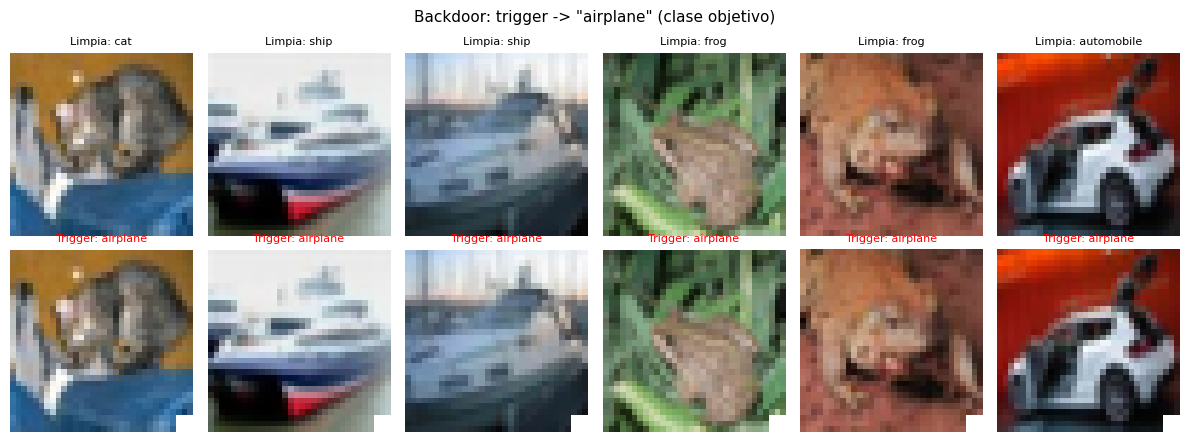

In [32]:
# Visualizar el backdoor en acción
model_bd.eval()
fig, axes = plt.subplots(2, 6, figsize=(12, 4.5))
testset_viz = torchvision.datasets.CIFAR10(root='./data', train=False, transform=T.ToTensor())
CIFAR_CLASSES = ('airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck')
shown = 0
for idx in range(len(testset_viz)):
    if shown >= 6: break
    x, y = testset_viz[idx]
    if y == TARGET_CLASS: continue
    with torch.no_grad():
        clean_pred = model_bd(x.unsqueeze(0).to(device)).argmax(1).item()
        x_trig = add_trigger(x)
        trig_pred = model_bd(x_trig.unsqueeze(0).to(device)).argmax(1).item()
    axes[0, shown].imshow(x.permute(1,2,0).numpy())
    axes[0, shown].set_title(f'Limpia: {CIFAR_CLASSES[clean_pred]}', fontsize=8)
    axes[0, shown].axis('off')
    color = 'red' if trig_pred == TARGET_CLASS else 'black'
    axes[1, shown].imshow(x_trig.permute(1,2,0).numpy())
    axes[1, shown].set_title(f'Trigger: {CIFAR_CLASSES[trig_pred]}', fontsize=8, color=color)
    axes[1, shown].axis('off')
    shown += 1
plt.suptitle(f'Backdoor: trigger -> "{CIFAR_CLASSES[TARGET_CLASS]}" (clase objetivo)', fontsize=11)
plt.tight_layout(); plt.savefig('backdoor_examples.pdf', bbox_inches='tight', dpi=150); plt.show()


### 16.4 Curva ASR vs porcentaje de envenenamiento

¿Cuánto envenenamiento se necesita para un backdoor efectivo? Entrenamos modelos con distintos `poison_rate` y medimos ASR y clean accuracy. (Usamos menos epochs por punto para que sea factible en tiempo.)


In [33]:
poison_rates = [0.001, 0.005, 0.01, 0.05, 0.10]
asr_curve, clean_curve = [], []
EPOCHS_SWEEP = 15   # menos epochs por punto para acelerar el barrido

for pr in poison_rates:
    ptrain = PoisonedCIFAR(trainset_clean, pr, TARGET_CLASS, seed=1)
    ploader = DataLoader(ptrain, batch_size=128, shuffle=True, num_workers=2)
    m = make_resnet18().to(device)
    o = optim.SGD(m.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
    s = optim.lr_scheduler.CosineAnnealingLR(o, T_max=EPOCHS_SWEEP)
    m.train()
    for ep in range(EPOCHS_SWEEP):
        for x, y in ploader:
            x, y = x.to(device), y.to(device)
            o.zero_grad(); loss = criterion(m(x), y); loss.backward(); o.step()
        s.step()
    ca = evaluate(m, test_loader)
    asr = attack_success_rate(m, test_loader, TARGET_CLASS)
    asr_curve.append(asr); clean_curve.append(ca)
    print(f"poison={pr*100:5.1f}% | clean acc={ca:.4f} | ASR={asr:.4f}")


Envenenadas 50 de 50000 imágenes (0.1%)
poison=  0.1% | clean acc=0.9030 | ASR=0.0153
Envenenadas 250 de 50000 imágenes (0.5%)
poison=  0.5% | clean acc=0.9077 | ASR=0.9192
Envenenadas 500 de 50000 imágenes (1.0%)
poison=  1.0% | clean acc=0.9073 | ASR=0.9319
Envenenadas 2500 de 50000 imágenes (5.0%)
poison=  5.0% | clean acc=0.9069 | ASR=0.9700
Envenenadas 5000 de 50000 imágenes (10.0%)
poison= 10.0% | clean acc=0.8992 | ASR=0.9773


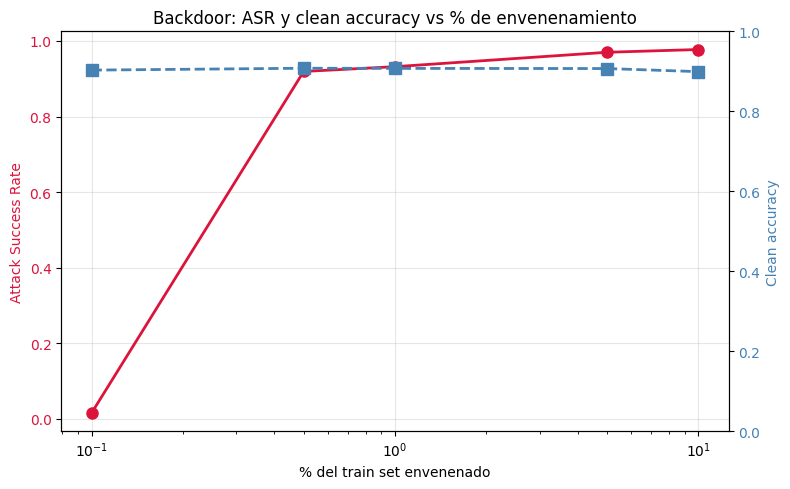

Observación: incluso con <1% de envenenamiento el ASR suele ser alto,
mientras la clean accuracy apenas cambia. Eso hace al backdoor difícil de detectar.


In [34]:
fig, ax1 = plt.subplots(figsize=(8, 5))
xs = [p*100 for p in poison_rates]
ax1.plot(xs, asr_curve, 'o-', color='crimson', linewidth=2, markersize=8, label='ASR')
ax1.set_xlabel('% del train set envenenado')
ax1.set_ylabel('Attack Success Rate', color='crimson')
ax1.tick_params(axis='y', labelcolor='crimson')
ax1.set_xscale('log')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(xs, clean_curve, 's--', color='steelblue', linewidth=2, markersize=8, label='Clean acc')
ax2.set_ylabel('Clean accuracy', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')
ax2.set_ylim(0, 1)

plt.title('Backdoor: ASR y clean accuracy vs % de envenenamiento')
fig.tight_layout(); plt.savefig('backdoor_curve.pdf', bbox_inches='tight', dpi=150); plt.show()
print("Observación: incluso con <1% de envenenamiento el ASR suele ser alto,")
print("mientras la clean accuracy apenas cambia. Eso hace al backdoor difícil de detectar.")


## 17. Data poisoning

A diferencia del backdoor (que necesita un trigger en inferencia), el data poisoning busca degradar el modelo sin acceso posterior. Comparamos dos variantes.

### 17.1 Label-flipping (ataque de disponibilidad)

El más simple: voltear las etiquetas de un porcentaje del train set a una clase incorrecta aleatoria. El modelo aprende asociaciones erróneas y su accuracy general baja. Medimos el efecto en clean accuracy a distintos niveles de envenenamiento.


In [35]:
class LabelFlipCIFAR(Dataset):
    """Voltea las etiquetas de una fracción del dataset a una clase aleatoria distinta."""
    def __init__(self, base, flip_rate, num_classes=10, seed=0):
        self.base = base
        rng = np.random.RandomState(seed)
        n = len(base)
        self.flip = {}
        idxs = rng.choice(n, size=int(flip_rate*n), replace=False)
        for i in idxs:
            _, y = base[i]
            new_y = rng.randint(num_classes)
            while new_y == y:
                new_y = rng.randint(num_classes)
            self.flip[i] = new_y
        print(f"Etiquetas volteadas: {len(self.flip)} de {n} ({flip_rate*100:.0f}%)")
    def __len__(self): return len(self.base)
    def __getitem__(self, i):
        x, y = self.base[i]
        return x, self.flip.get(i, y)


In [36]:
flip_rates = [0.0, 0.1, 0.2, 0.4]
flip_clean_acc = []
EPOCHS_LF = 15

for fr in flip_rates:
    if fr == 0.0:
        ds = trainset_clean
        print(f"flip=0% (baseline)")
    else:
        ds = LabelFlipCIFAR(trainset_clean, fr, seed=2)
    loader = DataLoader(ds, batch_size=128, shuffle=True, num_workers=2)
    m = make_resnet18().to(device)
    o = optim.SGD(m.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
    s = optim.lr_scheduler.CosineAnnealingLR(o, T_max=EPOCHS_LF)
    m.train()
    for ep in range(EPOCHS_LF):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            o.zero_grad(); loss = criterion(m(x), y); loss.backward(); o.step()
        s.step()
    ca = evaluate(m, test_loader)
    flip_clean_acc.append(ca)
    print(f"  -> clean test accuracy: {ca:.4f}")


flip=0% (baseline)
  -> clean test accuracy: 0.9014
Etiquetas volteadas: 5000 de 50000 (10%)
  -> clean test accuracy: 0.8934
Etiquetas volteadas: 10000 de 50000 (20%)
  -> clean test accuracy: 0.8794
Etiquetas volteadas: 20000 de 50000 (40%)
  -> clean test accuracy: 0.8266


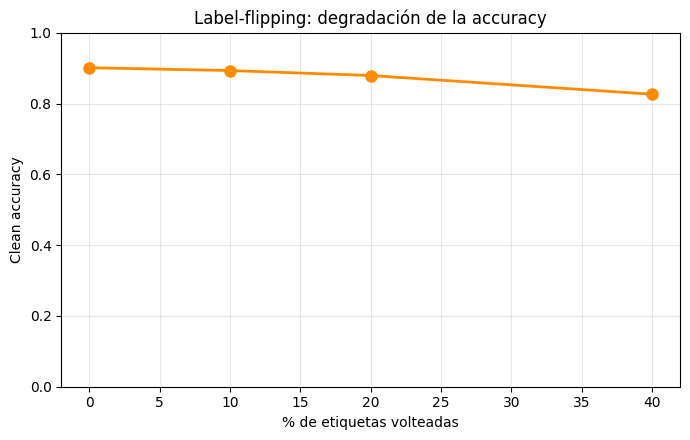

La accuracy decae de forma aproximadamente lineal con el % de etiquetas corruptas.


In [37]:
plt.figure(figsize=(7, 4.5))
plt.plot([f*100 for f in flip_rates], flip_clean_acc, 'o-', linewidth=2, markersize=8, color='darkorange')
plt.xlabel('% de etiquetas volteadas')
plt.ylabel('Clean accuracy')
plt.title('Label-flipping: degradación de la accuracy')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.tight_layout(); plt.savefig('labelflip_curve.pdf', bbox_inches='tight', dpi=150); plt.show()
print("La accuracy decae de forma aproximadamente lineal con el % de etiquetas corruptas.")


### 17.2 Clean-label poisoning (Poison Frogs, Shafahi et al. 2018)

El ataque más sofisticado: las imágenes envenenadas **mantienen su etiqueta correcta** (un humano revisando el dataset no detecta nada), pero se perturban para colisionar en el espacio de features con una imagen objetivo de otra clase.

**Objetivo:** que el modelo, tras entrenar, clasifique mal una imagen objetivo específica `x_target` (de clase base) como la clase del envenenamiento.

La perturbación resuelve:
$$x_{\text{poison}} = \arg\min_x \| \phi(x) - \phi(x_{\text{target}}) \|_2^2 + \beta \|x - x_{\text{base}}\|_2^2$$

donde $\phi$ es el extractor de features (penúltima capa). El primer término colisiona features con el objetivo; el segundo mantiene la imagen visualmente cercana a la base (clean-label).

**Nota importante:** Poison Frogs fue diseñado para *transfer learning / fine-tuning* (extractor de features congelado). En entrenamiento desde cero su efecto es mucho más débil. Aquí lo implementamos en el escenario realista de fine-tuning sobre nuestro modelo ya entrenado, para mostrar el mecanismo.


In [38]:
# Extractor de features: hasta la penúltima capa de la ResNet-18
def get_features(model, x):
    """Devuelve las features de la penúltima capa (antes de la fc final)."""
    net = model[1]              # model = Sequential(NormalizeLayer, resnet)
    z = model[0](x)             # normalizar
    z = net.conv1(z); z = net.bn1(z); z = net.relu(z); z = net.maxpool(z)
    z = net.layer1(z); z = net.layer2(z); z = net.layer3(z); z = net.layer4(z)
    z = net.avgpool(z); z = torch.flatten(z, 1)
    return z                    # (B, 512)

def craft_poison_frog(model, x_base, x_target, beta=0.1, lr=0.01, steps=500):
    """Crea una imagen envenenada que colisiona en features con x_target
    pero se parece a x_base (mantiene la etiqueta de x_base)."""
    model.eval()
    x = x_base.clone().detach().to(device)
    x_t = x_target.clone().detach().to(device)
    with torch.no_grad():
        feat_target = get_features(model, x_t.unsqueeze(0))
    x_poison = x.clone().detach().requires_grad_(True)
    opt = torch.optim.Adam([x_poison], lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        feat = get_features(model, x_poison.unsqueeze(0))
        loss_feat = ((feat - feat_target)**2).sum()
        loss_base = beta * ((x_poison - x)**2).sum()
        (loss_feat + loss_base).backward()
        opt.step()
        with torch.no_grad():
            x_poison.clamp_(0, 1)
    return x_poison.detach().cpu()


In [39]:
# Demostración sobre un par (target, base)
testset_cl = torchvision.datasets.CIFAR10(root='./data', train=False, transform=T.ToTensor())

# Buscar un target de clase 'bird'(2) y una base de clase 'dog'(5)
def find_example(ds, cls, start=0):
    for i in range(start, len(ds)):
        if ds[i][1] == cls: return ds[i][0], i
x_target, _ = find_example(testset_cl, 2)   # bird (objetivo a clasificar mal)
x_base, _   = find_example(testset_cl, 5)   # dog  (la imagen envenenada llevará etiqueta dog)

x_poison = craft_poison_frog(model_bd if False else model, x_base, x_target,
                             beta=0.1, steps=500)

# Comparar features
with torch.no_grad():
    f_base   = get_features(model, x_base.unsqueeze(0).to(device))
    f_target = get_features(model, x_target.unsqueeze(0).to(device))
    f_poison = get_features(model, x_poison.unsqueeze(0).to(device))
d_bt = (f_base - f_target).norm().item()
d_pt = (f_poison - f_target).norm().item()
print(f"Distancia en features base->target:   {d_bt:.3f}")
print(f"Distancia en features poison->target: {d_pt:.3f}")
print(f"Reducción: {(1 - d_pt/d_bt)*100:.0f}% más cerca del objetivo en feature space")
print(f"Perturbación visual L2 (poison vs base): {(x_poison - x_base).norm().item():.3f}")


Distancia en features base->target:   5.438
Distancia en features poison->target: 0.451
Reducción: 92% más cerca del objetivo en feature space
Perturbación visual L2 (poison vs base): 0.989


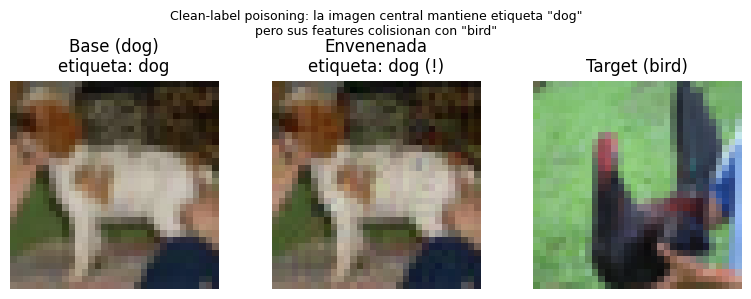

In [40]:
# Visualizar: la imagen envenenada parece un perro pero sus features son de pájaro
fig, axes = plt.subplots(1, 3, figsize=(8, 3))
axes[0].imshow(x_base.permute(1,2,0).numpy()); axes[0].set_title('Base (dog)\netiqueta: dog'); axes[0].axis('off')
axes[1].imshow(x_poison.permute(1,2,0).numpy()); axes[1].set_title('Envenenada\netiqueta: dog (!)'); axes[1].axis('off')
axes[2].imshow(x_target.permute(1,2,0).numpy()); axes[2].set_title('Target (bird)'); axes[2].axis('off')
plt.suptitle('Clean-label poisoning: la imagen central mantiene etiqueta "dog"\npero sus features colisionan con "bird"', fontsize=9)
plt.tight_layout(); plt.savefig('cleanlabel_demo.pdf', bbox_inches='tight', dpi=150); plt.show()


## 18. Tabla resumen y comparación de ataques en entrenamiento

In [41]:
print("="*68)
print("RESUMEN PARTE III — Ataques en tiempo de entrenamiento (CIFAR-10)")
print("="*68)
print(f"{'Ataque':<22}{'Tipo':<22}{'Efecto principal'}")
print("-"*68)
print(f"{'Backdoor (BadNets)':<22}{'Integridad+trigger':<22}{'ASR alto, clean acc intacta'}")
print(f"{'Label-flipping':<22}{'Disponibilidad':<22}{'Baja clean acc global'}")
print(f"{'Clean-label (Frogs)':<22}{'Integridad dirigida':<22}{'Colisión en features'}")
print("="*68)
print(f"\nBackdoor 5%:  clean acc={clean_acc_bd:.4f}, ASR={asr_bd:.4f}")
print(f"Label-flip 40%: clean acc={flip_clean_acc[-1]:.4f} (vs {flip_clean_acc[0]:.4f} baseline)")


RESUMEN PARTE III — Ataques en tiempo de entrenamiento (CIFAR-10)
Ataque                Tipo                  Efecto principal
--------------------------------------------------------------------
Backdoor (BadNets)    Integridad+trigger    ASR alto, clean acc intacta
Label-flipping        Disponibilidad        Baja clean acc global
Clean-label (Frogs)   Integridad dirigida   Colisión en features

Backdoor 5%:  clean acc=0.9267, ASR=0.9741
Label-flip 40%: clean acc=0.8266 (vs 0.9014 baseline)


## 19. Conclusiones de la Parte III

- **Backdoor (BadNets)** es la amenaza más sigilosa: con tan solo ~1-5% de envenenamiento, el modelo alcanza ASR muy alto mientras mantiene la clean accuracy casi intacta. Esto lo hace difícil de detectar mediante validación estándar (el modelo "se ve" sano).
- **Label-flipping** es un ataque de disponibilidad ruidoso: degrada la accuracy global de forma proporcional al % de etiquetas corruptas, pero es fácil de detectar (el modelo rinde mal) y de mitigar (limpieza de datos).
- **Clean-label poisoning** es conceptualmente el más elegante: mantiene etiquetas correctas y solo perturba imperceptiblemente. Su mecanismo (colisión en el espacio de features) es potente en escenarios de fine-tuning, aunque su efecto en entrenamiento desde cero es más limitado.
- **Comparación con ataques de evasión (Partes I-II):** los ataques de entrenamiento no requieren acceso al modelo en inferencia (el daño ya está incrustado en los pesos), lo que representa un vector de amenaza distinto y complementario. Un atacante con acceso a la cadena de suministro de datos (datasets públicos, scraping, crowdsourcing) puede comprometer modelos antes de que se entrenen.

### Defensas (trabajo futuro)
- Backdoor: Neural Cleanse, Activation Clustering, Spectral Signatures, fine-pruning.
- Poisoning: detección de outliers, entrenamiento robusto, sanitización de datos, differential privacy.

## Referencias (Parte III)

1. Gu, Dolan-Gavitt, Garg. *BadNets: Identifying Vulnerabilities in the Machine Learning Model Supply Chain*. 2017.
2. Shafahi et al. *Poison Frogs! Targeted Clean-Label Poisoning Attacks on Neural Networks*. NeurIPS 2018.
3. Biggio, Nelson, Laskov. *Poisoning Attacks against Support Vector Machines*. ICML 2012.
4. Wang et al. *Neural Cleanse: Identifying and Mitigating Backdoor Attacks*. IEEE S&P 2019.
